In [ ]:
from networks.cnn_dilated_convolutions import CNNModel
import duckdb
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

con = duckdb.connect('../capillary.db')

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"


df = con.execute(""" 
SELECT id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
""").df()
con.close()

df = df[
    (df['fractions'].apply(len) == 6) &
    (df['boundaries'].apply(len) == 12)
]
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

from scipy.ndimage import uniform_filter1d

feature_names = [
    "Alb%", "A1%", "A2%", "B%", "Beta2%", "Gamma",
    *[f"Gräns {i}" for i in range(12)],
    "Albumin", "Antitrypsin", "Orosomukoid",
    "Haptoglobin", "CRP", "IgG", "IgA", "IgM"
]

def plot_saliency(saliency_curve, saliency_tabular, raw_curve=None, smooth=False, smooth_size=10):
    """
    Args:
        saliency_curve:   (300,)
        saliency_tabular: (26,)
        raw_curve:        (300,) om du vill plotta råsignalen ovanför, annars None
        smooth:           True om du kör på enskilt sample
        smooth_size:      Smoothing-fönster, ignoreras om smooth=False
    """
    sal = uniform_filter1d(saliency_curve, size=smooth_size) if smooth else saliency_curve

    # --- Kurva ---
    if raw_curve is not None:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
        fig.suptitle("Saliency – kurvsignal", fontsize=14)
        ax1.plot(range(300), raw_curve, color="steelblue", linewidth=1.2)
        ax1.set_ylabel("Signalvärde")
        ax2.plot(range(300), sal, color="tomato", linewidth=1.5)
        ax2.fill_between(range(300), sal, alpha=0.3, color="tomato")
        ax2.set_ylabel("Saliency")
        ax2.set_xlabel("Mätpunkt")
    else:
        fig, ax2 = plt.subplots(figsize=(12, 3))
        ax2.set_title("Saliency – kurvsignal")
        ax2.plot(range(300), sal, color="tomato", linewidth=1.5)
        ax2.fill_between(range(300), sal, alpha=0.3, color="tomato")
        ax2.set_ylabel("Saliency")
        ax2.set_xlabel("Mätpunkt")

    plt.tight_layout()
    plt.show()

    # --- Tabellfeatures ---
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(range(26), saliency_tabular, color="steelblue")
    ax.set_xticks(range(26))
    ax.set_xticklabels(feature_names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Saliency")
    ax.set_title("d(score)/d(input) – tabellfeatures")
    plt.tight_layout()
    plt.show()

IOException: IO Error: Could not set lock on file "/Users/assarleideman/exjobb/capillary.db": Conflicting lock is held in /Library/Frameworks/Python.framework/Versions/3.13/Resources/Python.app/Contents/MacOS/Python (PID 52031) by user assarleideman. See also https://duckdb.org/docs/stable/connect/concurrency

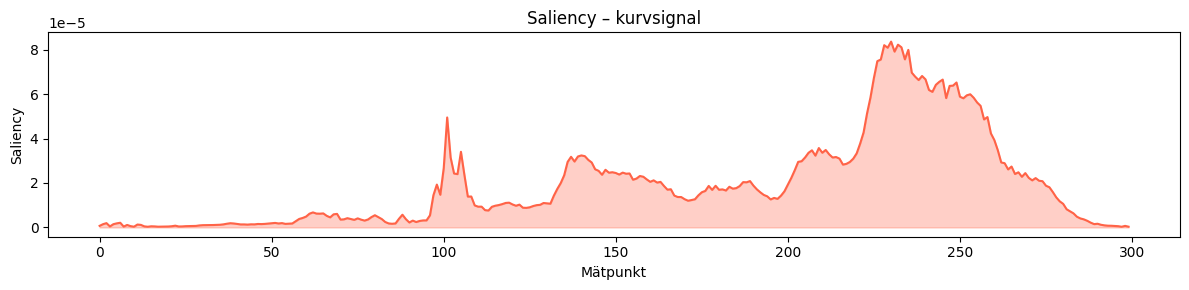

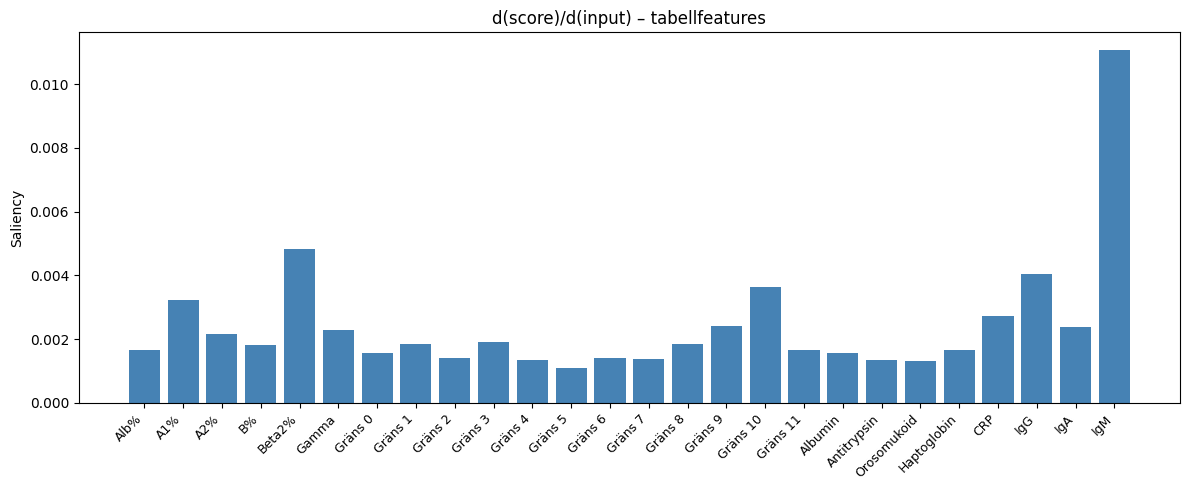

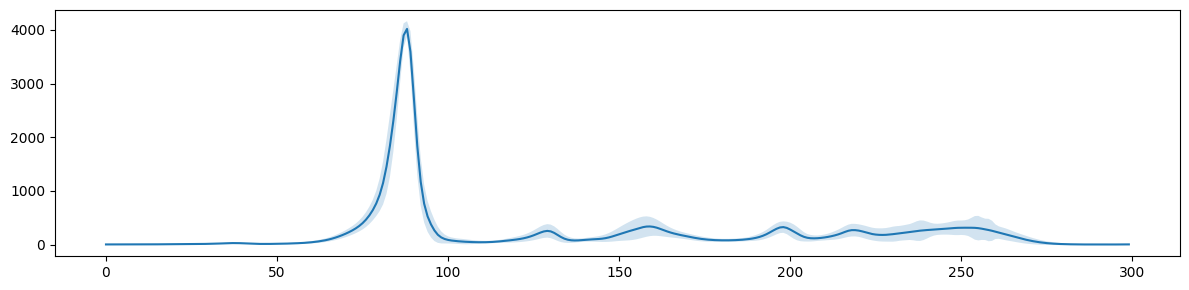

In [49]:
## Kolla hur den hittar M-komponent
model = CNNModel()

X_np = model._build_X(df)
model = model.model

batch_size = 512
batch_idx = 10

x = torch.tensor(X_np).to(device)
model.eval()

x.requires_grad_(True)
logits = model(x[batch_idx*batch_size:(batch_idx+1)*batch_size])
score  = logits[:, 1].sum()
score.backward()
grads = x.grad.detach().cpu().numpy()
saliency_curve   = np.abs(grads[:, :300])  
saliency_tabular = np.abs(grads[:, 300:])
saliency_curve = np.mean(saliency_curve,axis=0)
saliency_tabular = np.mean(saliency_tabular,axis=0)

plot_saliency(saliency_curve, saliency_tabular)
rows = df.loc[batch_idx*batch_size:(batch_idx+1)*batch_size,:]
value = np.stack(rows['value'].values)
avg_line = np.mean(value,axis=0)
std = np.std(value,axis=0)

plt.figure(figsize=(12,3))
plt.plot(range(300),avg_line)
plt.fill_between(range(300),avg_line-std,avg_line+std,alpha=0.2)
plt.tight_layout()
plt.show()

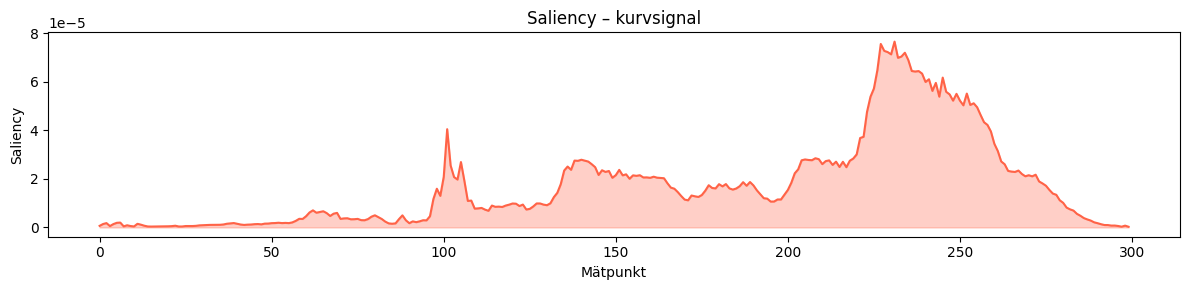

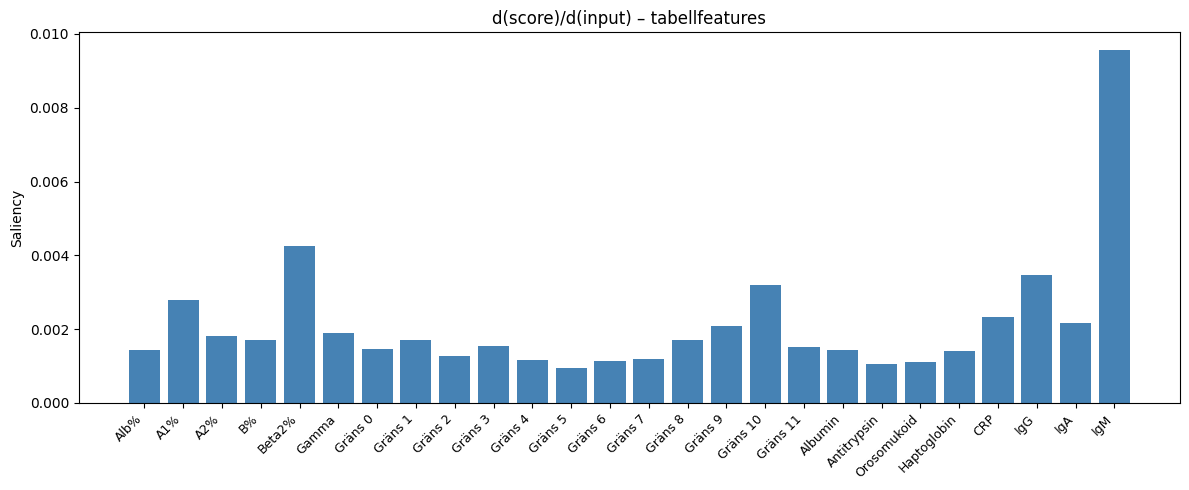

In [50]:
## Kolla hur den hittar friska komponenter
model = CNNModel()

X_np = model._build_X(df)
model = model.model

x = torch.tensor(X_np).to(device)
model.eval()

x.requires_grad_(True)
logits = model(x[0:512])
score  = logits[:, 0].sum()
score.backward()
grads = x.grad.detach().cpu().numpy()
saliency_curve   = np.abs(grads[:, :300])  
saliency_tabular = np.abs(grads[:, 300:])

saliency_curve = np.mean(saliency_curve,axis=0)
saliency_tabular = np.mean(saliency_tabular,axis=0)

plot_saliency(saliency_curve, saliency_tabular)


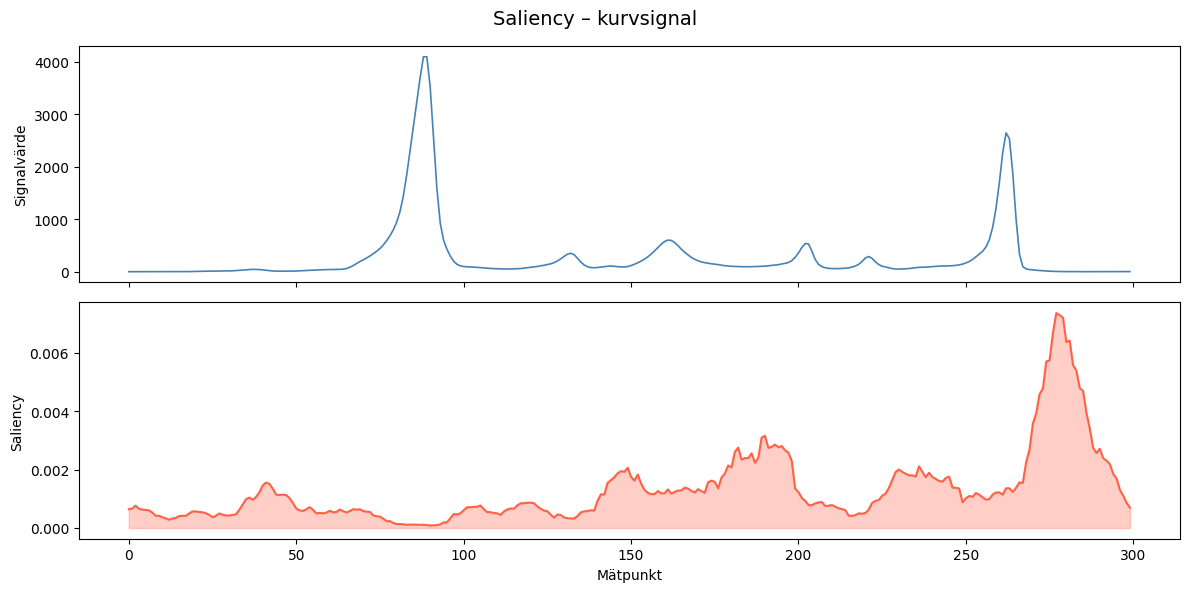

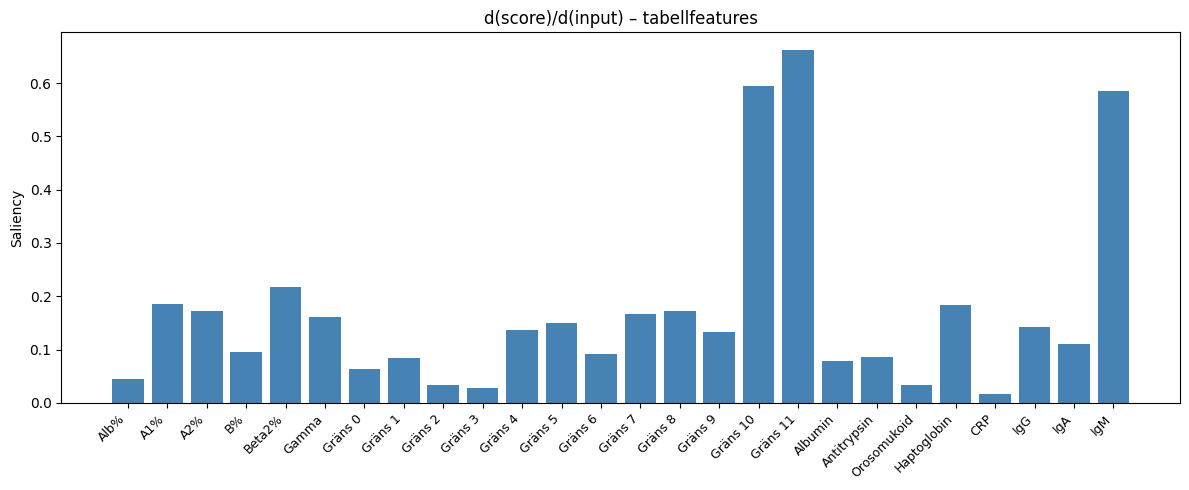

In [51]:
model = CNNModel()
idx = 16
df = df[df['label'] == 1].reset_index(drop=True)
row = df.iloc[idx]  # Första raden med label=1

X_np = model._build_X(pd.DataFrame([row]))
model = model.model

x = torch.tensor(X_np).to(device).float().clone()
x.requires_grad_(True)
logits = model(x)
score  = logits[:, 1].sum()
score.backward()
grads = x.grad.detach().cpu().numpy()
saliency_curve   = np.abs(grads[:, :300])  
saliency_tabular = np.abs(grads[:, 300:])
saliency_curve = np.mean(saliency_curve,axis=0)
saliency_tabular = np.mean(saliency_tabular,axis=0)

plot_saliency(saliency_curve, saliency_tabular, 
              raw_curve=df.loc[idx, 'value'], 
              smooth=True)